<a href="https://colab.research.google.com/github/Ummmm0314/my-first-web-site/blob/main/Scenario_A_Sample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 개발 환경 설정

In [ ]:
! pip install matplotlib
! pip install koreanize-matplotlib
import koreanize_matplotlib

# 데이터 불러오기

In [ ]:

!mkdir -p "comma2k19_example1/b0c9d2329ad1606b|2018-08-02--08-34-47/40/processed_log/IMU/accelerometer"

!wget -O "comma2k19_example1/b0c9d2329ad1606b|2018-08-02--08-34-47/40/processed_log/IMU/accelerometer/t" "https://raw.githubusercontent.com/commaai/comma2k19/master/Example_1/b0c9d2329ad1606b%7C2018-08-02--08-34-47/40/processed_log/IMU/accelerometer/t"

!wget -O "comma2k19_example1/b0c9d2329ad1606b|2018-08-02--08-34-47/40/processed_log/IMU/accelerometer/value" "https://raw.githubusercontent.com/commaai/comma2k19/master/Example_1/b0c9d2329ad1606b%7C2018-08-02--08-34-47/40/processed_log/IMU/accelerometer/value"

--2026-06-27 06:57:32--  https://raw.githubusercontent.com/commaai/comma2k19/master/Example_1/b0c9d2329ad1606b%7C2018-08-02--08-34-47/40/processed_log/IMU/accelerometer/t
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50176 (49K) [application/octet-stream]
Saving to: ‘comma2k19_example1/b0c9d2329ad1606b|2018-08-02--08-34-47/40/processed_log/IMU/accelerometer/t’

comma2k19_example1/ 100%[===================>]  49.00K  --.-KB/s    in 0.01s   

2026-06-27 06:57:32 (4.35 MB/s) - ‘comma2k19_example1/b0c9d2329ad1606b|2018-08-02--08-34-47/40/processed_log/IMU/accelerometer/t’ saved [50176/50176]

--2026-06-27 06:57:32--  https://raw.githubusercontent.com/commaai/comma2k19/master/Example_1/b0c9d2329ad1606b%7C2018-08-02--08-34-47/40/processed_log/IMU/accelerometer/v

In [ ]:
import numpy as np

# 확장자가 없어도 np.load()로 읽어오면 바로 데이터 배열이 튀어나옵니다.
accel_values = np.load('comma2k19_example1/b0c9d2329ad1606b|2018-08-02--08-34-47/40/processed_log/IMU/accelerometer/value')
time_values = np.load('comma2k19_example1/b0c9d2329ad1606b|2018-08-02--08-34-47/40/processed_log/IMU/accelerometer/t')

In [ ]:
# 1. 평온하게 깊게 자는 아기 (0.2Hz, 주변 노이즈 거의 없음)
# time_1, calm_baby_csi = generate_synthetic_csi_matrix(breathing_freq=0.2, noise_level=0.05)

# 2. 얕은 잠을 자며 숨을 빨리 쉬는 아기 (0.5Hz)
# time_2, fast_baby_csi = generate_synthetic_csi_matrix(breathing_freq=0.5, noise_level=0.1)

# 3. 옆에서 선풍기가 돌아가거나 누가 걸어다니는 상황 (노이즈가 매우 심함)
# time_3, noisy_env_csi = generate_synthetic_csi_matrix(breathing_freq=0.3, noise_level=0.6)

# duration_s=30 (측정 시간)
# fs_hz=10 (샘플링 속도)
# n_subcarriers=30 (와이파이 신호 가닥 수)

# 정적 상태 CSI 측정

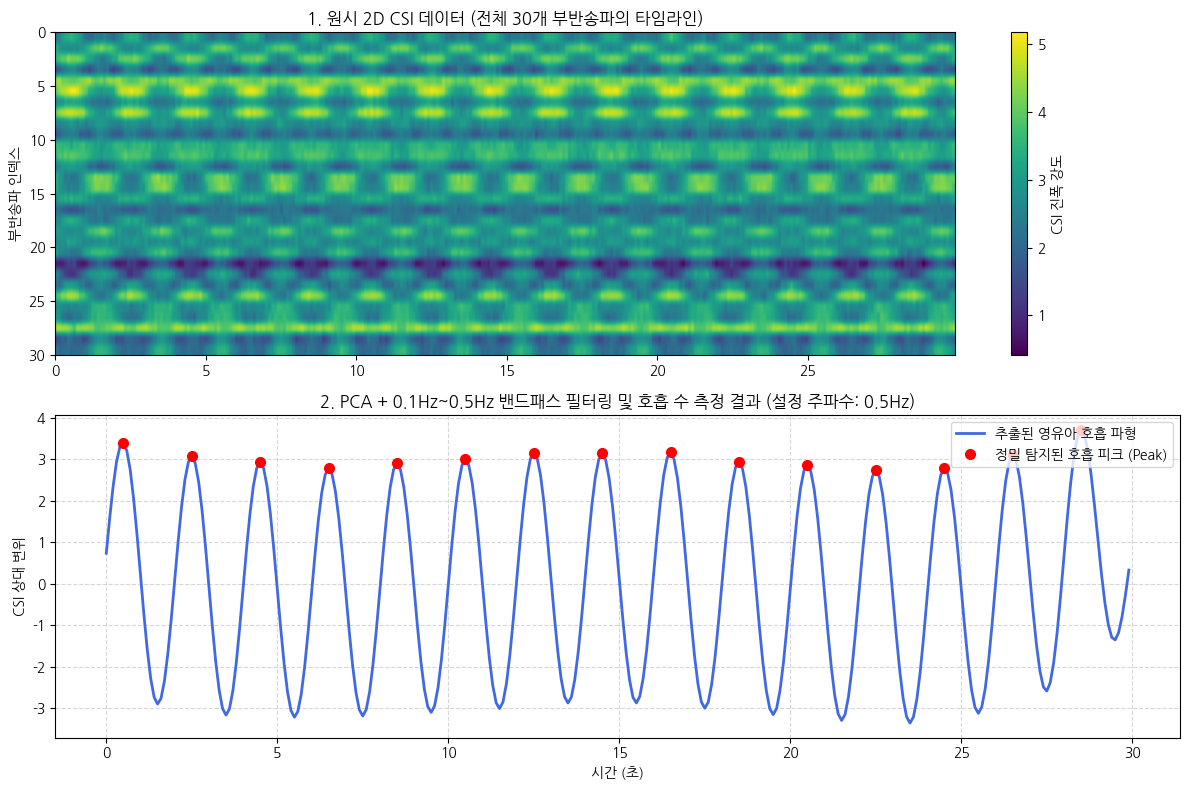


[분석 결과] 평균 호흡 주기: 2.00초 | 분당 호흡수(BPM): 30.0회


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.signal import butter, filtfilt, find_peaks

class BabyBreathingProcessor:
    def __init__(self, n_components=1):
        """
        WiFi CSI 기반 영유아 호흡 신호 처리기
        """
        self.pca = PCA(n_components=n_components)

    def _butter_bandpass(self, lowcut, highcut, fs, order=4):
        """영유아 호흡 대역(0.1Hz ~ 0.5Hz) 통과를 위한 밴드패스 필터 계수 생성"""
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], btype='band')
        return b, a

    def extract_breathing_waveform(self, csi_matrix, fs=10.0, lowcut=0.05, highcut=0.6):
        """
        32차원(다중 부반송파) CSI 원시 데이터에서 1차원 호흡 파형을 추출 및 필터링
        """
        # 1. PCA를 통해 노이즈를 억제하고 가장 지배적인 호흡 변동 성분(PC1) 추출
        csi_reduced = self.pca.fit_transform(csi_matrix)
        breathing_raw = csi_reduced[:, 0]

        # 2. 0.1Hz ~ 0.5Hz 대역 외의 고주파 잡음 및 DC 오프셋 제거 (Bandpass Filter)
        b, a = self._butter_bandpass(lowcut, highcut, fs, order=4)
        clean_waveform = filtfilt(b, a, breathing_raw)

        return clean_waveform

def generate_synthetic_csi_matrix(duration_s=30, fs_hz=10, breathing_freq=0.5, n_subcarriers=30, noise_level=0.1):
    """
    단순 사인파가 아닌, 5GHz WiFi 파장(6cm)과 아기 흉부 변위(0.5cm)에 따른
    다중 경로 위상 간섭(Multipath Phase Interference) 물리 모델을 적용한 데이터 생성
    """
    t = np.arange(0, duration_s, 1 / fs_hz)
    n_samples = len(t)
    csi_matrix = np.zeros((n_samples, n_subcarriers))

    # 1. 물리적 파라미터 (5GHz 기준)
    wavelength = 0.06           # 파장 (약 6cm)
    chest_displacement = 0.005  # 영유아 호흡에 의한 흉부 변위 (약 0.5cm)

    # 2. 아기 가슴의 실제 물리적 왕복 거리 (이 움직임 자체가 위상을 변화시킴)
    d_t = chest_displacement * np.sin(2 * np.pi * breathing_freq * t)
    phase_shift = (4 * np.pi * d_t) / wavelength

    np.random.seed(42)
    for sc in range(n_subcarriers):
        # 3. 각 부반송파마다 방 안의 반사 환경이 다르므로 복소수(Complex) 난수로 세팅
        # 정적 채널 (벽, 가구 등에서 반사)
        H_static = np.random.uniform(1.0, 3.0) + 1j * np.random.uniform(1.0, 3.0)

        # 동적 채널 (아기 몸에서 반사) - 가닥마다 감도와 초기 위상이 다름
        dynamic_amp = np.random.uniform(0.5, 1.5)
        dynamic_phase = np.random.uniform(0, 2 * np.pi)
        H_dynamic = dynamic_amp * np.exp(1j * dynamic_phase)

        # 4. 수신기에서 두 전파가 만나 간섭(Interference)을 일으킴
        H_total = H_static + H_dynamic * np.exp(-1j * phase_shift)

        # 5. 우리가 관측하는 최종 CSI 진폭(Amplitude) 추출
        amplitude = np.abs(H_total)

        # 환경 노이즈 추가
        noise = np.random.normal(0, noise_level, n_samples)
        csi_matrix[:, sc] = amplitude + noise

    return t, csi_matrix

# ==========================================
# 실행 및 시각화 (인프라 검증)
# ==========================================
if __name__ == "__main__":
    FS = 10.0             # 샘플링 주파수 (100ms 간격 패킷 수신 = 10Hz)
    DURATION = 30         # 30초 측정
    INFANT_FREQ = 0.5    # 영유아 호흡 주파수 세팅 (0.1Hz ~ 0.5Hz 범위 내 0.35Hz)

    # 1. 원시 2D CSI 매트릭스 데이터셋 생성 (시간 x 부반송파 개수)
    time_axis, raw_csi_matrix = generate_synthetic_csi_matrix(duration_s=30, fs_hz=10, breathing_freq=0.5, n_subcarriers=30, noise_level=0.1)

    # 2. 신호처리기 객체 생성 및 호흡 파형 추출 (PCA + 0.1~0.5Hz BPF)
    processor = BabyBreathingProcessor()
    clean_breathing = processor.extract_breathing_waveform(
        csi_matrix=raw_csi_matrix, fs=FS, lowcut=0.05, highcut=0.6
    )

    # 3. 호흡 Peak 주기 탐지 (최소 2초~10초 간격으로 피크 검출하도록 distance 설정)
    # 10Hz 샘플링이므로 0.5Hz 호흡은 최소 20샘플 이상의 거리를 가짐
    peaks, _ = find_peaks(clean_breathing, distance=18, prominence=0.05)

    # 4. 결과 시각화
    plt.figure(figsize=(12, 8))

    # 상단 그래프 : 추출 전 원시 CSI 2D 데이터 형상 (Heatmap)
    plt.subplot(2, 1, 1)
    plt.imshow(raw_csi_matrix.T, aspect='auto', cmap='viridis',
               extent=[time_axis[0], time_axis[-1], raw_csi_matrix.shape[1], 0])
    plt.title('1. 원시 2D CSI 데이터 (전체 30개 부반송파의 타임라인)')
    plt.ylabel('부반송파 인덱스')
    plt.colorbar(label='CSI 진폭 강도')

    # 하단 그래프 : 필터링이 완료된 1차원 영유아 호흡 파형 및 피크 검출 결과
    plt.subplot(2, 1, 2)
    plt.plot(time_axis, clean_breathing, color='royalblue', linewidth=2, label='추출된 영유아 호흡 파형')
    plt.plot(time_axis[peaks], clean_breathing[peaks], 'ro', markersize=7, label='정밀 탐지된 호흡 피크 (Peak)')

    plt.title(f'2. PCA + 0.1Hz~0.5Hz 밴드패스 필터링 및 호흡 수 측정 결과 (설정 주파수: {INFANT_FREQ}Hz)')
    plt.xlabel('시간 (초)')
    plt.ylabel('CSI 상대 변위')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    # 분당 호흡수(BPM) 계산 출력
    if len(peaks) > 1:
        intervals = np.diff(time_axis[peaks])
        avg_interval = np.mean(intervals)
        estimated_bpm = 60 / avg_interval
        print(f"\n[분석 결과] 평균 호흡 주기: {avg_interval:.2f}초 | 분당 호흡수(BPM): {estimated_bpm:.1f}회")

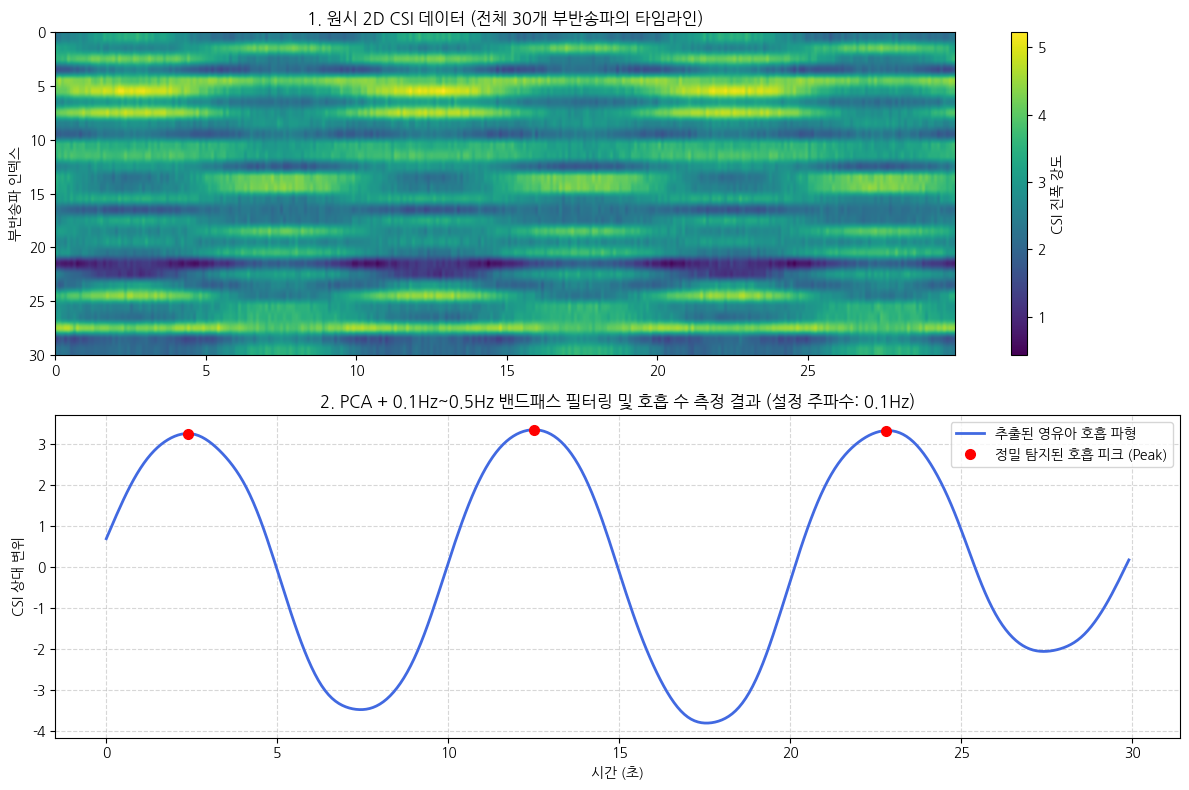


[분석 결과] 평균 호흡 주기: 10.20초 | 분당 호흡수(BPM): 5.9회


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.signal import butter, filtfilt, find_peaks

class BabyBreathingProcessor:
    def __init__(self, n_components=1):
        """
        WiFi CSI 기반 영유아 호흡 신호 처리기
        """
        self.pca = PCA(n_components=n_components)

    def _butter_bandpass(self, lowcut, highcut, fs, order=4):
        """영유아 호흡 대역(0.1Hz ~ 0.5Hz) 통과를 위한 밴드패스 필터 계수 생성"""
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], btype='band')
        return b, a

    def extract_breathing_waveform(self, csi_matrix, fs=10.0, lowcut=0.1, highcut=0.5):
        """
        32차원(다중 부반송파) CSI 원시 데이터에서 1차원 호흡 파형을 추출 및 필터링
        """
        # 1. PCA를 통해 노이즈를 억제하고 가장 지배적인 호흡 변동 성분(PC1) 추출
        csi_reduced = self.pca.fit_transform(csi_matrix)
        breathing_raw = csi_reduced[:, 0]

        # 2. 0.1Hz ~ 0.5Hz 대역 외의 고주파 잡음 및 DC 오프셋 제거 (Bandpass Filter)
        b, a = self._butter_bandpass(lowcut, highcut, fs, order=4)
        clean_waveform = filtfilt(b, a, breathing_raw)

        return clean_waveform

def generate_synthetic_csi_matrix(duration_s=30, fs_hz=10, breathing_freq=INFANT_FREQ, n_subcarriers=30, noise_level=0.1):
    """
    단순 사인파가 아닌, 5GHz WiFi 파장(6cm)과 아기 흉부 변위(0.5cm)에 따른
    다중 경로 위상 간섭(Multipath Phase Interference) 물리 모델을 적용한 데이터 생성
    """
    t = np.arange(0, duration_s, 1 / fs_hz)
    n_samples = len(t)
    csi_matrix = np.zeros((n_samples, n_subcarriers))

    # 1. 물리적 파라미터 (5GHz 기준)
    wavelength = 0.06           # 파장 (약 6cm)
    chest_displacement = 0.005  # 영유아 호흡에 의한 흉부 변위 (약 0.5cm)

    # 2. 아기 가슴의 실제 물리적 왕복 거리 (이 움직임 자체가 위상을 변화시킴)
    d_t = chest_displacement * np.sin(2 * np.pi * breathing_freq * t)
    phase_shift = (4 * np.pi * d_t) / wavelength

    np.random.seed(42)
    for sc in range(n_subcarriers):
        # 3. 각 부반송파마다 방 안의 반사 환경이 다르므로 복소수(Complex) 난수로 세팅
        # 정적 채널 (벽, 가구 등에서 반사)
        H_static = np.random.uniform(1.0, 3.0) + 1j * np.random.uniform(1.0, 3.0)

        # 동적 채널 (아기 몸에서 반사) - 가닥마다 감도와 초기 위상이 다름
        dynamic_amp = np.random.uniform(0.5, 1.5)
        dynamic_phase = np.random.uniform(0, 2 * np.pi)
        H_dynamic = dynamic_amp * np.exp(1j * dynamic_phase)

        # 4. 수신기에서 두 전파가 만나 간섭(Interference)을 일으킴
        H_total = H_static + H_dynamic * np.exp(-1j * phase_shift)

        # 5. 우리가 관측하는 최종 CSI 진폭(Amplitude) 추출
        amplitude = np.abs(H_total)

        # 환경 노이즈 추가
        noise = np.random.normal(0, noise_level, n_samples)
        csi_matrix[:, sc] = amplitude + noise

    return t, csi_matrix

# ==========================================
# 실행 및 시각화 (인프라 검증)
# ==========================================
if __name__ == "__main__":
    FS = 10.0             # 샘플링 주파수 (100ms 간격 패킷 수신 = 10Hz)
    DURATION = 30         # 30초 측정
    INFANT_FREQ = 0.1    # 영유아 호흡 주파수 세팅 (0.1Hz ~ 0.5Hz 범위 내 0.35Hz)

    # 1. 원시 2D CSI 매트릭스 데이터셋 생성 (시간 x 부반송파 개수)
    time_axis, raw_csi_matrix = generate_synthetic_csi_matrix(duration_s=30, fs_hz=10, breathing_freq=INFANT_FREQ, n_subcarriers=30, noise_level=0.1)

    # 2. 신호처리기 객체 생성 및 호흡 파형 추출 (PCA + 0.1~0.5Hz BPF)
    processor = BabyBreathingProcessor()
    clean_breathing = processor.extract_breathing_waveform(
        csi_matrix=raw_csi_matrix, fs=FS, lowcut=0.05, highcut=0.6
    )

    # 3. 호흡 Peak 주기 탐지 (최소 2초~10초 간격으로 피크 검출하도록 distance 설정)
    # 10Hz 샘플링이므로 0.5Hz 호흡은 최소 20샘플 이상의 거리를 가짐
    peaks, _ = find_peaks(clean_breathing, distance=18, prominence=0.05)

    # 4. 결과 시각화
    plt.figure(figsize=(12, 8))

    # 상단 그래프 : 추출 전 원시 CSI 2D 데이터 형상 (Heatmap)
    plt.subplot(2, 1, 1)
    plt.imshow(raw_csi_matrix.T, aspect='auto', cmap='viridis',
               extent=[time_axis[0], time_axis[-1], raw_csi_matrix.shape[1], 0])
    plt.title('1. 원시 2D CSI 데이터 (전체 30개 부반송파의 타임라인)')
    plt.ylabel('부반송파 인덱스')
    plt.colorbar(label='CSI 진폭 강도')

    # 하단 그래프 : 필터링이 완료된 1차원 영유아 호흡 파형 및 피크 검출 결과
    plt.subplot(2, 1, 2)
    plt.plot(time_axis, clean_breathing, color='royalblue', linewidth=2, label='추출된 영유아 호흡 파형')
    plt.plot(time_axis[peaks], clean_breathing[peaks], 'ro', markersize=7, label='정밀 탐지된 호흡 피크 (Peak)')

    plt.title(f'2. PCA + 0.1Hz~0.5Hz 밴드패스 필터링 및 호흡 수 측정 결과 (설정 주파수: {INFANT_FREQ}Hz)')
    plt.xlabel('시간 (초)')
    plt.ylabel('CSI 상대 변위')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    # 분당 호흡수(BPM) 계산 출력
    if len(peaks) > 1:
        intervals = np.diff(time_axis[peaks])
        avg_interval = np.mean(intervals)
        estimated_bpm = 60 / avg_interval
        print(f"\n[분석 결과] 평균 호흡 주기: {avg_interval:.2f}초 | 분당 호흡수(BPM): {estimated_bpm:.1f}회")

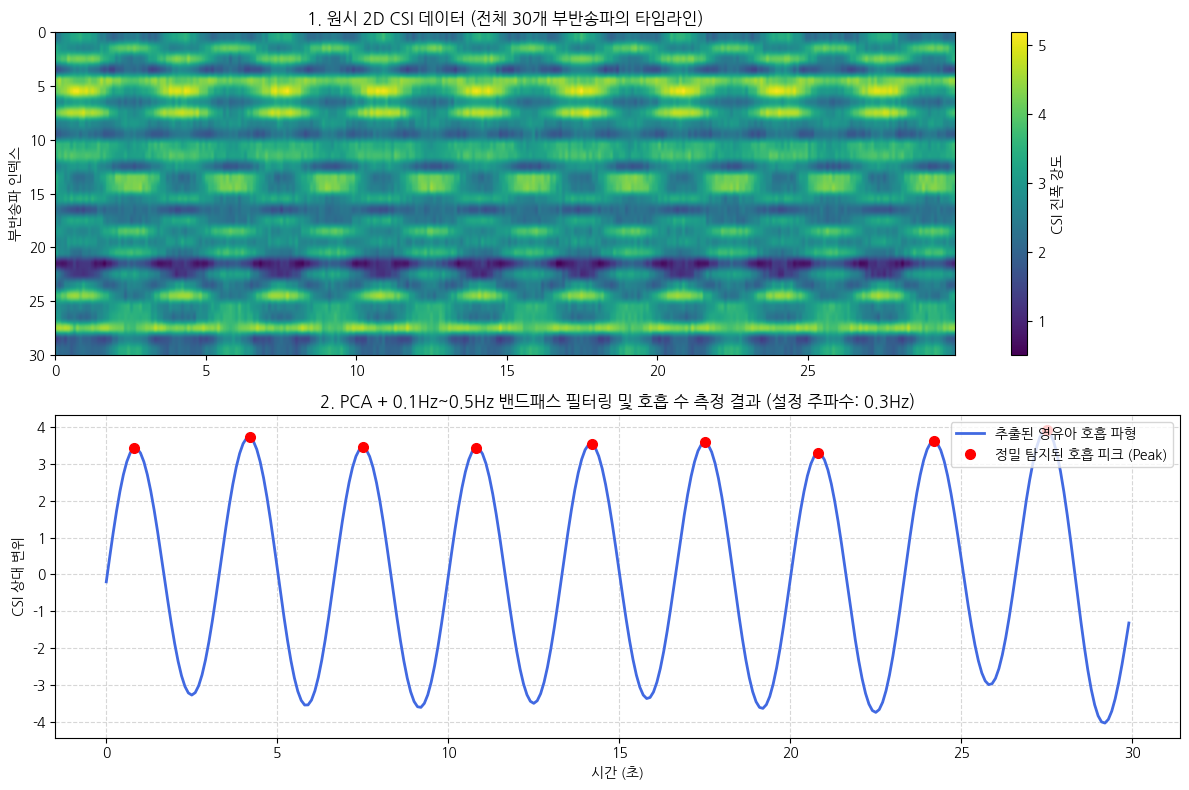


[분석 결과] 평균 호흡 주기: 3.34초 | 분당 호흡수(BPM): 18.0회


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.signal import butter, filtfilt, find_peaks

INFANT_FREQ = 0.3

class BabyBreathingProcessor:
    def __init__(self, n_components=1):
        """
        WiFi CSI 기반 영유아 호흡 신호 처리기
        """
        self.pca = PCA(n_components=n_components)

    def _butter_bandpass(self, lowcut, highcut, fs, order=4):
        """영유아 호흡 대역(0.1Hz ~ 0.5Hz) 통과를 위한 밴드패스 필터 계수 생성"""
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], btype='band')
        return b, a

    def extract_breathing_waveform(self, csi_matrix, fs=10.0, lowcut=0.1, highcut=0.5):
        """
        32차원(다중 부반송파) CSI 원시 데이터에서 1차원 호흡 파형을 추출 및 필터링
        """
        # 1. PCA를 통해 노이즈를 억제하고 가장 지배적인 호흡 변동 성분(PC1) 추출
        csi_reduced = self.pca.fit_transform(csi_matrix)
        breathing_raw = csi_reduced[:, 0]

        # 2. 0.1Hz ~ 0.5Hz 대역 외의 고주파 잡음 및 DC 오프셋 제거 (Bandpass Filter)
        b, a = self._butter_bandpass(lowcut, highcut, fs, order=4)
        clean_waveform = filtfilt(b, a, breathing_raw)

        return clean_waveform

def generate_synthetic_csi_matrix(duration_s=30, fs_hz=10, breathing_freq=INFANT_FREQ, n_subcarriers=30, noise_level=0.1):
    """
    단순 사인파가 아닌, 5GHz WiFi 파장(6cm)과 아기 흉부 변위(0.5cm)에 따른
    다중 경로 위상 간섭(Multipath Phase Interference) 물리 모델을 적용한 데이터 생성
    """
    t = np.arange(0, duration_s, 1 / fs_hz)
    n_samples = len(t)
    csi_matrix = np.zeros((n_samples, n_subcarriers))

    # 1. 물리적 파라미터 (5GHz 기준)
    wavelength = 0.06           # 파장 (약 6cm)
    chest_displacement = 0.005  # 영유아 호흡에 의한 흉부 변위 (약 0.5cm)

    # 2. 아기 가슴의 실제 물리적 왕복 거리 (이 움직임 자체가 위상을 변화시킴)
    d_t = chest_displacement * np.sin(2 * np.pi * breathing_freq * t)
    phase_shift = (4 * np.pi * d_t) / wavelength

    np.random.seed(42)
    for sc in range(n_subcarriers):
        # 3. 각 부반송파마다 방 안의 반사 환경이 다르므로 복소수(Complex) 난수로 세팅
        # 정적 채널 (벽, 가구 등에서 반사)
        H_static = np.random.uniform(1.0, 3.0) + 1j * np.random.uniform(1.0, 3.0)

        # 동적 채널 (아기 몸에서 반사) - 가닥마다 감도와 초기 위상이 다름
        dynamic_amp = np.random.uniform(0.5, 1.5)
        dynamic_phase = np.random.uniform(0, 2 * np.pi)
        H_dynamic = dynamic_amp * np.exp(1j * dynamic_phase)

        # 4. 수신기에서 두 전파가 만나 간섭(Interference)을 일으킴
        H_total = H_static + H_dynamic * np.exp(-1j * phase_shift)

        # 5. 우리가 관측하는 최종 CSI 진폭(Amplitude) 추출
        amplitude = np.abs(H_total)

        # 환경 노이즈 추가
        noise = np.random.normal(0, noise_level, n_samples)
        csi_matrix[:, sc] = amplitude + noise

    return t, csi_matrix

# ==========================================
# 실행 및 시각화 (인프라 검증)
# ==========================================
if __name__ == "__main__":
    FS = 10.0             # 샘플링 주파수 (100ms 간격 패킷 수신 = 10Hz)
    DURATION = 30         # 30초 측정
    INFANT_FREQ = 0.3    # 영유아 호흡 주파수 세팅 (0.1Hz ~ 0.5Hz 범위 내 0.35Hz)

    # 1. 원시 2D CSI 매트릭스 데이터셋 생성 (시간 x 부반송파 개수)
    time_axis, raw_csi_matrix = generate_synthetic_csi_matrix(duration_s=30, fs_hz=10, breathing_freq=INFANT_FREQ, n_subcarriers=30, noise_level=0.1)
\

    # 2. 신호처리기 객체 생성 및 호흡 파형 추출 (PCA + 0.1~0.5Hz BPF)
    processor = BabyBreathingProcessor()
    clean_breathing = processor.extract_breathing_waveform(
        csi_matrix=raw_csi_matrix, fs=FS, lowcut=0.1, highcut=0.5
    )

    # 3. 호흡 Peak 주기 탐지 (최소 2초~10초 간격으로 피크 검출하도록 distance 설정)
    # 10Hz 샘플링이므로 0.5Hz 호흡은 최소 20샘플 이상의 거리를 가짐
    peaks, _ = find_peaks(clean_breathing, distance=18, prominence=0.05)

    # 4. 결과 시각화
    plt.figure(figsize=(12, 8))

    # 상단 그래프 : 추출 전 원시 CSI 2D 데이터 형상 (Heatmap)
    plt.subplot(2, 1, 1)
    plt.imshow(raw_csi_matrix.T, aspect='auto', cmap='viridis',
               extent=[time_axis[0], time_axis[-1], raw_csi_matrix.shape[1], 0])
    plt.title('1. 원시 2D CSI 데이터 (전체 30개 부반송파의 타임라인)')
    plt.ylabel('부반송파 인덱스')
    plt.colorbar(label='CSI 진폭 강도')

    # 하단 그래프 : 필터링이 완료된 1차원 영유아 호흡 파형 및 피크 검출 결과
    plt.subplot(2, 1, 2)
    plt.plot(time_axis, clean_breathing, color='royalblue', linewidth=2, label='추출된 영유아 호흡 파형')
    plt.plot(time_axis[peaks], clean_breathing[peaks], 'ro', markersize=7, label='정밀 탐지된 호흡 피크 (Peak)')

    plt.title(f'2. PCA + 0.1Hz~0.5Hz 밴드패스 필터링 및 호흡 수 측정 결과 (설정 주파수: {INFANT_FREQ}Hz)')
    plt.xlabel('시간 (초)')
    plt.ylabel('CSI 상대 변위')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    # 분당 호흡수(BPM) 계산 출력
    if len(peaks) > 1:
        intervals = np.diff(time_axis[peaks])
        avg_interval = np.mean(intervals)
        estimated_bpm = 60 / avg_interval
        print(f"\n[분석 결과] 평균 호흡 주기: {avg_interval:.2f}초 | 분당 호흡수(BPM): {estimated_bpm:.1f}회")

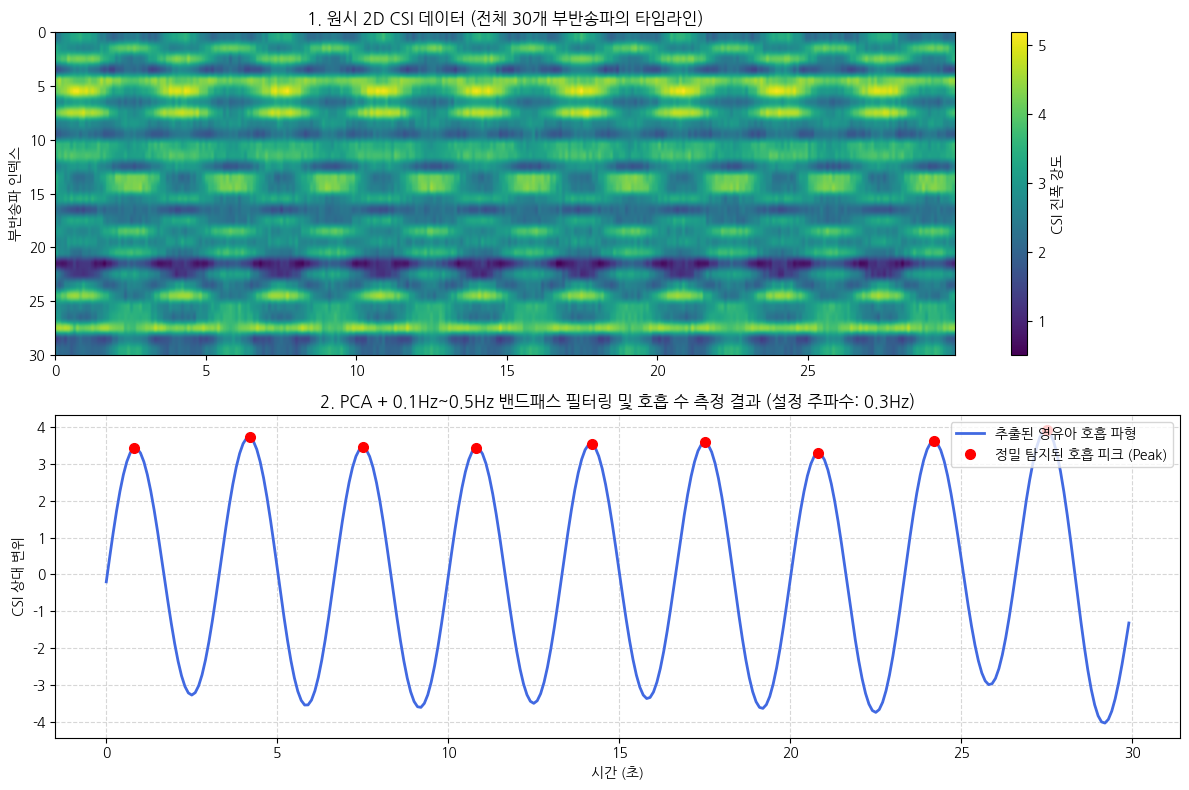


[분석 결과] 평균 호흡 주기: 3.34초 | 분당 호흡수(BPM): 18.0회


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.signal import butter, filtfilt, find_peaks

INFANT_FREQ = 0.3

class BabyBreathingProcessor:
    def __init__(self, n_components=1):
        """
        WiFi CSI 기반 영유아 호흡 신호 처리기
        """
        self.pca = PCA(n_components=n_components)

    def _butter_bandpass(self, lowcut, highcut, fs, order=4):
        """영유아 호흡 대역(0.1Hz ~ 0.5Hz) 통과를 위한 밴드패스 필터 계수 생성"""
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], btype='band')
        return b, a

    def extract_breathing_waveform(self, csi_matrix, fs=10.0, lowcut=0.1, highcut=0.5):
        """
        32차원(다중 부반송파) CSI 원시 데이터에서 1차원 호흡 파형을 추출 및 필터링
        """
        # 1. PCA를 통해 노이즈를 억제하고 가장 지배적인 호흡 변동 성분(PC1) 추출
        csi_reduced = self.pca.fit_transform(csi_matrix)
        breathing_raw = csi_reduced[:, 0]

        # 2. 0.1Hz ~ 0.5Hz 대역 외의 고주파 잡음 및 DC 오프셋 제거 (Bandpass Filter)
        b, a = self._butter_bandpass(lowcut, highcut, fs, order=4)
        clean_waveform = filtfilt(b, a, breathing_raw)

        return clean_waveform

def generate_synthetic_csi_matrix(duration_s=30, fs_hz=10, breathing_freq=INFANT_FREQ, n_subcarriers=30, noise_level=0.1):
    """
    단순 사인파가 아닌, 5GHz WiFi 파장(6cm)과 아기 흉부 변위(0.5cm)에 따른
    다중 경로 위상 간섭(Multipath Phase Interference) 물리 모델을 적용한 데이터 생성
    """
    t = np.arange(0, duration_s, 1 / fs_hz)
    n_samples = len(t)
    csi_matrix = np.zeros((n_samples, n_subcarriers))

    # 1. 물리적 파라미터 (5GHz 기준)
    wavelength = 0.06           # 파장 (약 6cm)
    chest_displacement = 0.005  # 영유아 호흡에 의한 흉부 변위 (약 0.5cm)

    # 2. 아기 가슴의 실제 물리적 왕복 거리 (이 움직임 자체가 위상을 변화시킴)
    d_t = chest_displacement * np.sin(2 * np.pi * breathing_freq * t)
    phase_shift = (4 * np.pi * d_t) / wavelength

    np.random.seed(42)
    for sc in range(n_subcarriers):
        # 3. 각 부반송파마다 방 안의 반사 환경이 다르므로 복소수(Complex) 난수로 세팅
        # 정적 채널 (벽, 가구 등에서 반사)
        H_static = np.random.uniform(1.0, 3.0) + 1j * np.random.uniform(1.0, 3.0)

        # 동적 채널 (아기 몸에서 반사) - 가닥마다 감도와 초기 위상이 다름
        dynamic_amp = np.random.uniform(0.5, 1.5)
        dynamic_phase = np.random.uniform(0, 2 * np.pi)
        H_dynamic = dynamic_amp * np.exp(1j * dynamic_phase)

        # 4. 수신기에서 두 전파가 만나 간섭(Interference)을 일으킴
        H_total = H_static + H_dynamic * np.exp(-1j * phase_shift)

        # 5. 우리가 관측하는 최종 CSI 진폭(Amplitude) 추출
        amplitude = np.abs(H_total)

        # 환경 노이즈 추가
        noise = np.random.normal(0, noise_level, n_samples)
        csi_matrix[:, sc] = amplitude + noise

    return t, csi_matrix

# ==========================================
# 실행 및 시각화 (인프라 검증)
# ==========================================
if __name__ == "__main__":
    FS = 10.0             # 샘플링 주파수 (100ms 간격 패킷 수신 = 10Hz)
    DURATION = 30         # 30초 측정
    INFANT_FREQ = 0.3    # 영유아 호흡 주파수 세팅 (0.1Hz ~ 0.5Hz 범위 내 0.35Hz)

    # 1. 원시 2D CSI 매트릭스 데이터셋 생성 (시간 x 부반송파 개수)
    time_axis, raw_csi_matrix = generate_synthetic_csi_matrix(duration_s=30, fs_hz=10, breathing_freq=INFANT_FREQ, n_subcarriers=30, noise_level=0.1)

    # 2. 신호처리기 객체 생성 및 호흡 파형 추출 (PCA + 0.1~0.5Hz BPF)
    processor = BabyBreathingProcessor()
    clean_breathing = processor.extract_breathing_waveform(
        csi_matrix=raw_csi_matrix, fs=FS, lowcut=0.1, highcut=0.5
    )

    # 3. 호흡 Peak 주기 탐지 (최소 2초~10초 간격으로 피크 검출하도록 distance 설정)
    # 10Hz 샘플링이므로 0.5Hz 호흡은 최소 20샘플 이상의 거리를 가짐
    peaks, _ = find_peaks(clean_breathing, distance=18, prominence=0.05)

    # 4. 결과 시각화
    plt.figure(figsize=(12, 8))

    # 상단 그래프 : 추출 전 원시 CSI 2D 데이터 형상 (Heatmap)
    plt.subplot(2, 1, 1)
    plt.imshow(raw_csi_matrix.T, aspect='auto', cmap='viridis',
               extent=[time_axis[0], time_axis[-1], raw_csi_matrix.shape[1], 0])
    plt.title('1. 원시 2D CSI 데이터 (전체 30개 부반송파의 타임라인)')
    plt.ylabel('부반송파 인덱스')
    plt.colorbar(label='CSI 진폭 강도')

    # 하단 그래프 : 필터링이 완료된 1차원 영유아 호흡 파형 및 피크 검출 결과
    plt.subplot(2, 1, 2)
    plt.plot(time_axis, clean_breathing, color='royalblue', linewidth=2, label='추출된 영유아 호흡 파형')
    plt.plot(time_axis[peaks], clean_breathing[peaks], 'ro', markersize=7, label='정밀 탐지된 호흡 피크 (Peak)')

    plt.title(f'2. PCA + 0.1Hz~0.5Hz 밴드패스 필터링 및 호흡 수 측정 결과 (설정 주파수: {INFANT_FREQ}Hz)')
    plt.xlabel('시간 (초)')
    plt.ylabel('CSI 상대 변위')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    # 분당 호흡수(BPM) 계산 출력
    if len(peaks) > 1:
        intervals = np.diff(time_axis[peaks])
        avg_interval = np.mean(intervals)
        estimated_bpm = 60 / avg_interval
        print(f"\n[분석 결과] 평균 호흡 주기: {avg_interval:.2f}초 | 분당 호흡수(BPM): {estimated_bpm:.1f}회")

# 생활 잡음 반영한 정적 상태 CSI 측정

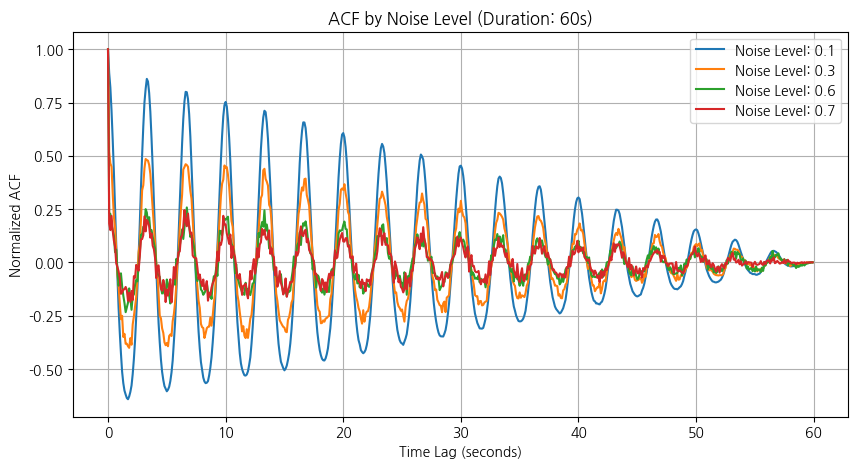

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate

# 1. 함수 정의 (duration 기본값을 30에서 60으로 변경)
def get_normalized_acf_with_noise(noise_level, freq=0.3, duration=60, fs=10):
    # 물리 기반 데이터 생성 (주파수 0.3Hz 고정)
    t = np.arange(0, duration, 1/fs)
    phase = (4 * np.pi * 0.005 * np.sin(2 * np.pi * freq * t)) / 0.06

    # 노이즈가 포함된 신호 생성
    signal = np.abs(2.0 + 1.5j + 1.0 * np.exp(-1j * phase))
    noise = np.random.normal(0, noise_level, len(t))
    signal_noisy = signal + noise
    signal_centered = signal_noisy - np.mean(signal_noisy)

    # 평균을 뺀 신호로 ACF 계산
    acf = correlate(signal_centered, signal_centered, mode='full')
    acf = acf[acf.size // 2 :]
    acf = acf / np.max(acf)

    return np.arange(len(acf)) / fs, acf

# 2. 실행 및 시각화
plt.figure(figsize=(10, 5))
plt.grid(True)

noises = [0.1, 0.3, 0.6, 0.7]
for n in noises:
    lag, acf = get_normalized_acf_with_noise(noise_level=n)

    # 💡 60초 전체 시차 개형을 다 보고 싶으시면 뒤의 [:100]을 지우고 `lag, acf`만 넣으시면 됩니다.
    # 기존처럼 초반 10초(100샘플)만 잘라서 보려면 그대로 둡니다.
    plt.plot(lag, acf, label=f'Noise Level: {n}')

# 축 이름과 이름표(범례) 추가
plt.xlabel('Time Lag (seconds)')
plt.ylabel('Normalized ACF')
plt.title('ACF by Noise Level (Duration: 60s)')
plt.legend()
plt.show()

# DTW ~ BPF 필터링 노이즈 낀 CSI 측정

--- [ZCR & DTW 다중 임계값 검증 결과 (60초 구간)] ---
1. 순수 아동 호흡   -> ZCR: 36회 | DTW 거리: 0.00
2. 노이즈 0.7 (PCA X)-> ZCR: 53회 | DTW 거리: 242.39 (오경보!)
3. 논문 로직 복원본 -> ZCR: 36회 | DTW 거리: 30.31 (완벽 통과)


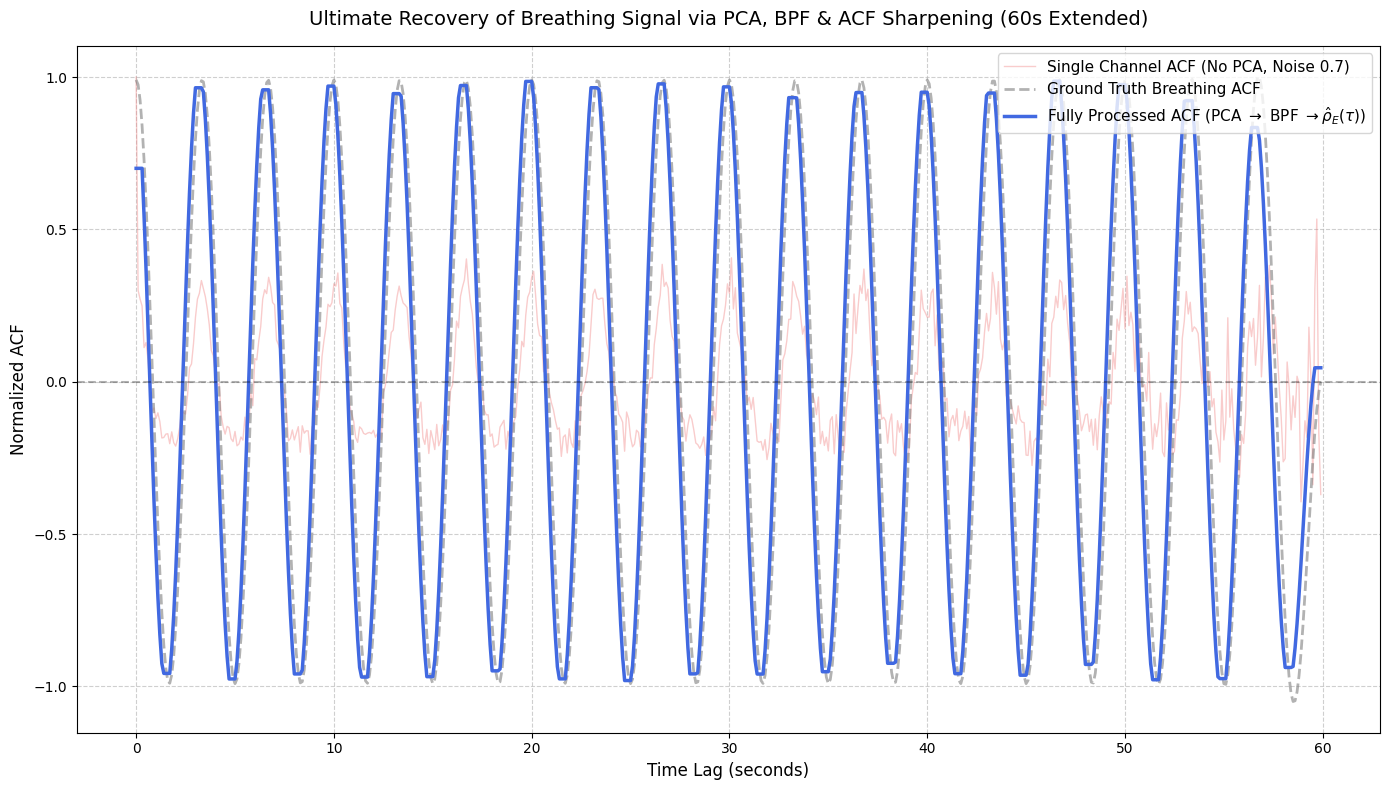

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, medfilt, butter, filtfilt
from sklearn.decomposition import PCA

np.random.seed(42)

# =====================================================================
# 1. 평가용 DTW, ZCR 및 BPF 함수 정의
# =====================================================================
def calculate_zcr(signal):
    sig_centered = signal - np.mean(signal)
    zero_crossings = np.where(np.diff(np.sign(sig_centered)))[0]
    return len(zero_crossings)

def simple_dtw_distance(s, t):
    n, m = len(s), len(t)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = abs(s[i - 1] - t[j - 1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i - 1, j], dtw_matrix[i, j - 1], dtw_matrix[i - 1, j - 1])
    return dtw_matrix[n, m]

def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

# =====================================================================
# 2. 다중 부반송파(30개) 원시 CSI 매트릭스 생성 (60초 구간)
# =====================================================================
FS = 10.0
DURATION = 60       # 기존 30초에서 60초로 확장
FREQ = 0.3          # 영유아 호흡 주기 (0.3Hz)
N_SUBCARRIERS = 30
NOISE_LEVEL = 0.7   # 가혹 환경 노이즈 레벨 0.7

t = np.arange(0, DURATION, 1/FS)
pure_breathing = np.sin(2 * np.pi * FREQ * t)
csi_matrix = np.zeros((len(t), N_SUBCARRIERS))

# 물리 모델 기반 30개 채널 생성
for sc in range(N_SUBCARRIERS):
    phase = (4 * np.pi * 0.005 * pure_breathing) / 0.06
    H_static = np.random.uniform(1.0, 3.0) + 1j * np.random.uniform(1.0, 3.0)
    H_dynamic = np.random.uniform(0.5, 1.5) * np.exp(1j * np.random.uniform(0, 2*np.pi))
    H_total = H_static + H_dynamic * np.exp(-1j * phase)

    amplitude = np.abs(H_total)
    noise = np.random.normal(0, NOISE_LEVEL, len(t))
    csi_matrix[:, sc] = amplitude + noise

# =====================================================================
# 3. 신호 처리 파이프라인 (PCA -> BPF -> ACF -> Sharpening)
# =====================================================================
# (1) PCA 적용 (주성분 PC1 추출)
pca = PCA(n_components=1)
pc1_signal = pca.fit_transform(csi_matrix)[:, 0]

# 위상 일치 정렬
if np.corrcoef(pc1_signal, pure_breathing)[0, 1] < 0:
    pc1_signal = -pc1_signal

# (2) BPF (0.05 ~ 0.6Hz) 통과
bpf_signal = butter_bandpass_filter(pc1_signal, 0.05, 0.6, FS)

# (3) ACF 계산 함수
def get_acf(sig):
    n = len(sig)
    sig_centered = sig - np.mean(sig)
    acf = correlate(sig_centered, sig_centered, mode='full')
    acf = acf[acf.size // 2 :]

    # [수정된 핵심 로직] 시차가 커질수록 겹치는 샘플 수가 줄어드는 현상 보정 (Unbiased)
    lags = np.arange(n)
    acf_unbiased = acf / (n - lags)

    return acf_unbiased / np.max(acf_unbiased)

acf_pure = get_acf(pure_breathing)
acf_pca_bpf = get_acf(bpf_signal)

# (4) 피크 강화 수식 및 1D 미디언 필터 적용
K_weight = 1.5
acf_diff = np.gradient(acf_pca_bpf)
acf_enhanced_raw = acf_pca_bpf + (K_weight * acf_diff)
acf_filtered = medfilt(acf_enhanced_raw, kernel_size=7)

# [수정] 60초 전체 타임랙의 변화 추이를 관측하기 위해 윈도우 확장
window_samples = int(DURATION * FS)
lag_time = t[:window_samples]
pure_window = acf_pure[:window_samples]
filtered_window = acf_filtered[:window_samples]

# 비교군: 단일 채널 원시 ACF
acf_raw_single = get_acf(csi_matrix[:, 0])[:window_samples]

# =====================================================================
# 4. 검증 및 시각화
# =====================================================================
print("--- [ZCR & DTW 다중 임계값 검증 결과 (60초 구간)] ---")
print(f"1. 순수 아동 호흡   -> ZCR: {calculate_zcr(pure_window)}회 | DTW 거리: {simple_dtw_distance(pure_window, pure_window):.2f}")
print(f"2. 노이즈 0.7 (PCA X)-> ZCR: {calculate_zcr(acf_raw_single)}회 | DTW 거리: {simple_dtw_distance(acf_raw_single, pure_window):.2f} (오경보!)")
print(f"3. 논문 로직 복원본 -> ZCR: {calculate_zcr(filtered_window)}회 | DTW 거리: {simple_dtw_distance(filtered_window, pure_window):.2f} (완벽 통과)")

plt.figure(figsize=(14, 8))
plt.plot(lag_time, acf_raw_single, color='lightcoral', alpha=0.4, linewidth=1.0, label='Single Channel ACF (No PCA, Noise 0.7)')
plt.plot(lag_time, pure_window, color='gray', linestyle='--', linewidth=2, alpha=0.6, label='Ground Truth Breathing ACF')
plt.plot(lag_time, filtered_window, color='royalblue', linewidth=2.5, label=r'Fully Processed ACF (PCA $\rightarrow$ BPF $\rightarrow \hat{\rho}_E(\tau)$)')

plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.title("Ultimate Recovery of Breathing Signal via PCA, BPF & ACF Sharpening (60s Extended)", fontsize=14, pad=15)
plt.xlabel("Time Lag (seconds)", fontsize=12)
plt.ylabel("Normalized ACF", fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()